In [ ]:
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
import numpy as np
import os
import slsim
import slsim.Sources as sources
from astropy.table import vstack
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
import matplotlib.pyplot as plt
from slsim.ImageSimulation.image_simulation import (
    point_source_coordinate_properties,
    lens_image_series,
    rgb_image_from_image_list,
    lens_image
)
from slsim.Plots.plot_functions import create_image_montage_from_image_list


import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from IPython.display import HTML

from astropy import units as u
import corner
from astropy.table import Table

# roman filters
import speclite
from configs import midex_speclite # configure the midex filters in this file
from slsim.Pipelines import roman_speclite

from slsim.ImageSimulation.roman_image_simulation import simulate_roman_image
from slsim.ImageSimulation.image_simulation import simulate_image, rgb_image_from_image_list

%load_ext autoreload
%autoreload 2

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/home/paras/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


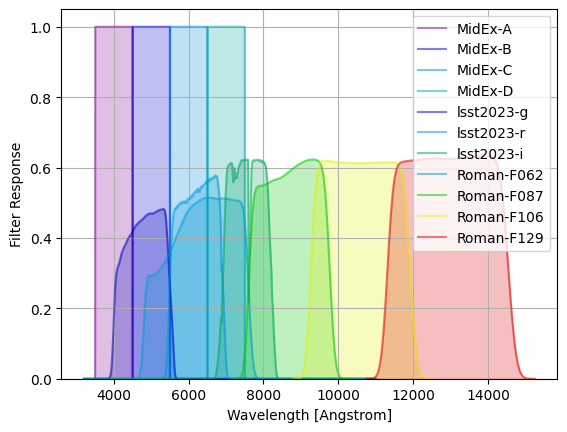

In [2]:
# 1. Generate and register the MidEx and Roman filters with speclite
midex_speclite.configure_midex_filters()
roman_speclite.configure_roman_filters()

# 2. Load them by their newly registered names
filters = speclite.filters.load_filters(
    "MidEx-A",
    "MidEx-B",
    "MidEx-C",
    "MidEx-D",
    # "lsst2023-u",
    "lsst2023-g",
    "lsst2023-r",
    "lsst2023-i",
    # "lsst2023-z",
    # "lsst2023-y",
    "Roman-F062",
    "Roman-F087",
    "Roman-F106",
    "Roman-F129",
)

# 3. Plot them
speclite.filters.plot_filters(filters)

In [ ]:
skypy_config = os.path.join("configs", "roman-lsst-MidEx-like.yml")

## Lensed quasar population

In [4]:
# define a cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)


# define a sky area
galaxy_sky_area = Quantity(value=2, unit="deg2")
quasar_sky_area = Quantity(value=5, unit="deg2")
full_sky_area = Quantity(value=10, unit="deg2")


# define limits in the intrinsic deflector and source population (in addition
# to the skypy config
# file)
kwargs_deflector_cut = {"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5}
kwargs_source_cut = {"band": "i", "band_max": 26, "z_min": 0.001, "z_max": 5.0}

# NOTE: By default only the i-band information is available for the quasar sources generated using the QuasarRate class.
# So for kwargs_source_cut, we need provide the i-band cuts.
# If you have any other band information available for a population of quasars, you can use that band instead,
# but then you'd use your own table of quasar properties instead of generating it using the QuasarRate class.

In [ ]:
# generate galaxy population using skypy pipeline.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config,
    sky_area=galaxy_sky_area,
    filters=None,
    cosmo=cosmo,
    z_min=0.0,
    z_max=3.0,
)
# NOTE: z_max is set to 3.0 because the MidEx-A filter is not available for z>3. This will be corrected in the future.
# We will eventually use the full redshift range of the skypy pipeline i.e. z_max=5.0.

# define host galaxy candidates for the quasars
host_galaxy_candidates = vstack(
    [galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies],
    join_type="exact",
)

In [7]:
# Initiate deflector popiulation class
lens_galaxies = deflectors.AllLensGalaxies(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=galaxy_sky_area,
)
# lens_galaxies = deflectors.EllipticalLensGalaxies(
#     galaxy_list=galaxy_simulation_pipeline.red_galaxies,
#     kwargs_cut=kwargs_deflector_cut,
#     kwargs_mass2light={},
#     cosmo=cosmo,
#     sky_area=galaxy_sky_area,
# )

/home/paras/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:56: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  red_galaxy_list = catalog_with_angular_size_in_arcsec(
/home/paras/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:59: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  blue_galaxy_list = catalog_with_angular_size_in_arcsec(


In [15]:
# Initiate QuasarRate class to generate quasar sample.
quasar_class = QuasarRate(
    skypy_config=skypy_config,
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    noise=True,
    redshifts=np.linspace(0.001, 5.01, 100),  # these redshifts are provided
    # to match general slsim redshift range in skypy pipeline.
    host_galaxy_candidate=host_galaxy_candidates,
    # To have realistic colors and magnitudes in Roman and LSST bands
    use_qsogen_sed=True,
    qsogen_bands=[
        "F062",
        "F087",
        "F106",
        "F129",
        "F158",
        "F184",
        "F146",
        "F213",  # Roman bands
        "g",
        "r",
        "i",
        "z",
        "y",  # LSST bands
        "MidEx-A",
        "MidEx-B",
        "MidEx-C",
        "MidEx-D",  # MidEx bands
    ],
    use_sed_interpolator=True,
)
quasar_source = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)

/home/paras/.venv/lib/python3.13/site-packages/speclite/filters.py:1119: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(maggies)
Matching quasars with host galaxies:   4%|▍         | 2248/52838 [00:00<00:11, 4336.63it/s]/home/paras/repos/self/slsim/slsim/Sources/SourceCatalogues/QuasarCatalog/quasar_host_match.py:123: RuntimeWarning: divide by zero encountered in log10
  M_bol = M_bol_sun - 2.5 * np.log10(L_bol)  # L_sun
Matching quasars with host galaxies: 100%|██████████| 52838/52838 [00:12<00:00, 4336.10it/s]


In [ ]:
# save quasar sample to a file
# quasar_source.write(f"data/agn+host_catalog_{quasar_sky_area.value}_deg2.fits", overwrite=True)
# quasar_source = Table.read(f"data/agn+host_catalog_{quasar_sky_area.value}_deg2.fits")

In [17]:
# Prepare dictionary of agn variability kwargs
variable_agn_kwarg_dict = {
    "length_of_light_curve": 35000,
    "time_resolution": 1,
    "log_breakpoint_frequency": 1 / 20,
    "low_frequency_slope": 1,
    "high_frequency_slope": 3,
    "standard_deviation": 0.9,
}

kwargs_quasar = {
    "variability_model": "light_curve",
    "kwargs_variability": {
        "agn_lightcurve",
        "i",
        "r",
        "g",
        "z",
        "y",
        "F184",
        "F146",
        "F129",
        "F106",
        "F062",
        "F158",
        "MidEx-A",
        "MidEx-B",
        "MidEx-C",
        "MidEx-D",
    },
    "agn_driving_variability_model": "bending_power_law",
    "agn_driving_kwargs_variability": variable_agn_kwarg_dict,
    "lightcurve_time": np.linspace(-5000, 30000, 35000),
    "corona_height": 10,
    "r_resolution": 500,
}
# Initiate source population class.
# source_quasar = sources.PointSources(
#     quasar_source,
#     cosmo=cosmo,
#     sky_area=quasar_sky_area,
#     kwargs_cut=kwargs_source_cut,
#     point_source_type="quasar",
#     point_source_kwargs=kwargs_quasar,
# )

# Point source quasar population with host galaxy
source_quasar = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_source,
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    kwargs_cut=kwargs_source_cut,
    list_type="astropy_table",
    catalog_type="skypy",
    point_source_type="quasar",
    extended_source_type="single_sersic",
    point_source_kwargs=kwargs_quasar,
)

In [18]:
# Initiate LensPop class to generate lensed quasar pop.
quasar_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=full_sky_area*100,
)

## Select a lens to visualize its lightcurves

In [19]:
# Select a random lens
kwargs_lens_cut = {"min_image_separation": 0.5, "max_image_separation": 10, 
                    "second_brightest_image_cut": {"i": 26}}

selected_lenses = quasar_lens_pop.draw_population(kwargs_lens_cuts = kwargs_lens_cut, speed_factor=10000)

quad_lenses = []
for lens_class in selected_lenses:
    if lens_class.image_number[0] == 4:
        quad_lenses.append(lens_class)

number of images:  [4]
einstein radius: 1.2498805255554248
source redshift: 2.8727715286213
deflector redshift: 0.8272595773533399
kappa_star:  [0.03173707 0.11124783 0.28191877 0.6923004 ]
kappa_tot:  [0.20036271 0.38435671 0.69531991 1.20395249]
shear:  [0.20035602 0.38436469 0.6953205  1.20395187]
shear_angle:  [ 1.75560677  3.0791669  -1.955266   -0.5431355 ]


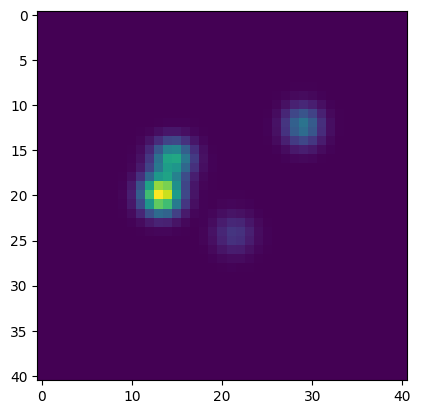

In [28]:
image_separations = []
for lens in quad_lenses:
    image_separations.append(lens.einstein_radius[0])

# choose the lens with the largest image separation for visualization
largest_image_separation_index = np.argmax(image_separations)
lens_class = quad_lenses[largest_image_separation_index]

x_pos_images, y_pos_images = lens_class.point_source_image_positions()[0]
print("number of images: ", lens_class.image_number)
print("einstein radius:", lens_class.einstein_radius[0])
print("source redshift:", lens_class.source_redshift_list[0])
print("deflector redshift:", lens_class.deflector_redshift)
kappa_star, kappa_tot, shear, shear_angle = lens_class._microlensing_parameters_for_image_positions_single_source(band="i", source_index=0)
print("kappa_star: ", kappa_star)
print("kappa_tot: ", kappa_tot)
print("shear: ", shear)
print("shear_angle: ", shear_angle)

from configs.midex_specs import MidEx
midex_kwargs_single_band = MidEx(band="D").kwargs_single_band()
plt.imshow(simulate_image(
    lens_class, band = "D",
    num_pix = 41, kwargs_single_band=midex_kwargs_single_band

))